In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)

In [ ]:
pd.read_csv("/content/drive/MyDrive/AIML_LAB/min_project /Obesity.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns)
print("Shape:", df.shape)


Columns: Index(['Age', 'Gender', 'Height', 'Weight', 'BMI', 'Label'], dtype='object')
Shape: (108, 6)


In [ ]:
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])


In [ ]:
target = 'Label'

In [ ]:
le = LabelEncoder()
df[target] = le.fit_transform(df[target])
class_names = le.classes_


In [ ]:
X = df.drop(columns=[target])
y = df[target]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(max_depth=6),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

In [76]:
results = []
all_predictions = {}

print("\nTraining Models...\n")

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        auc = roc_auc_score(
            label_binarize(y_test, classes=np.unique(y)),
            y_prob,
            multi_class='ovr',
            average='weighted'
        )
    else:
        auc = np.nan

    results.append([name, acc, precision, recall, f1, auc])
    all_predictions[name] = y_pred
print(classification_report(y_test, y_pred))



Training Models...

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training KNN...
Training Naive Bayes...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.50      1.00      0.67         2
           2       1.00      0.50      0.67         4
           3       1.00      1.00      1.00        10

    accuracy                           0.91        22
   macro avg       0.88      0.88      0.83        22
weighted avg       0.95      0.91      0.91        22



In [77]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"
])

results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("\nFinal Results:\n", results_df)



Final Results:
                  Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2        Random Forest  1.000000   1.000000  1.000000  1.000000  1.000000
3                  KNN  0.954545   0.963636  0.954545  0.955005  0.993213
1        Decision Tree  0.954545   0.961039  0.954545  0.953047  0.968750
4          Naive Bayes  0.909091   0.954545  0.909091  0.909091  0.997475
0  Logistic Regression  0.863636   0.861472  0.863636  0.859141  0.978535


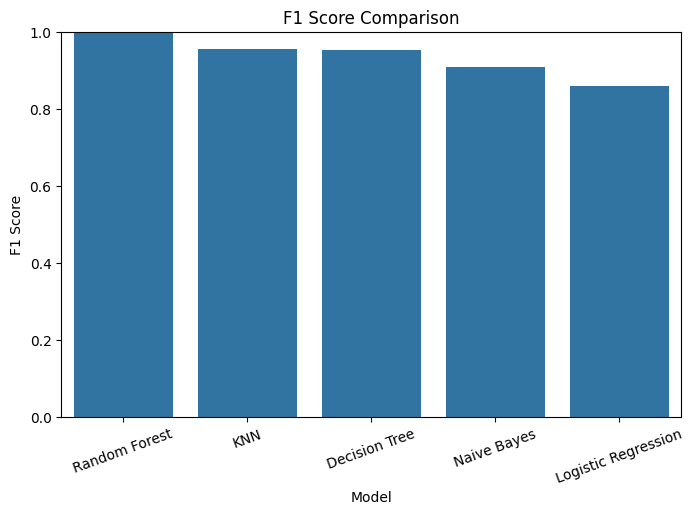

In [78]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x='Model', y='F1 Score')
plt.xticks(rotation=20)
plt.title("F1 Score Comparison")
plt.ylim(0,1)
plt.show()

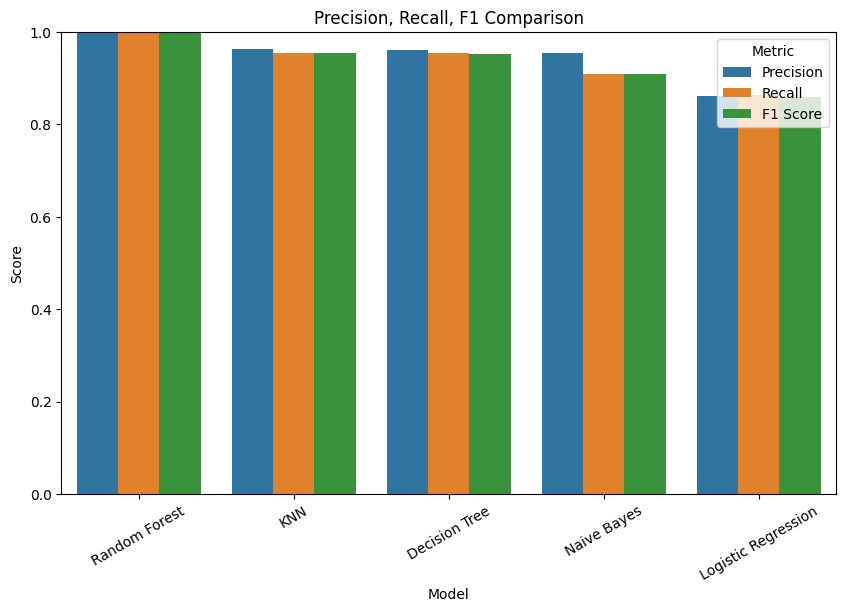

In [79]:
metrics_df = results_df[['Model', 'Precision', 'Recall', 'F1 Score']]
metrics_melted = metrics_df.melt('Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted)
plt.xticks(rotation=30)
plt.title("Precision, Recall, F1 Comparison")
plt.ylim(0,1)
plt.show()


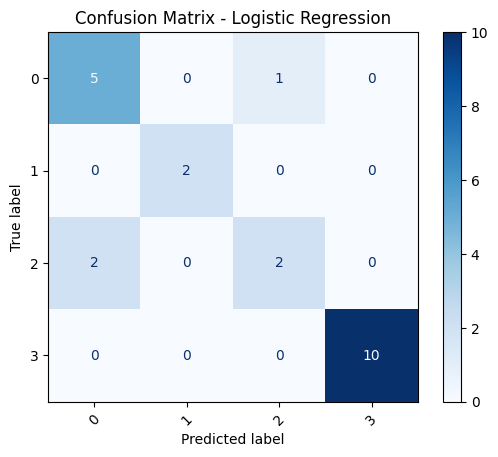

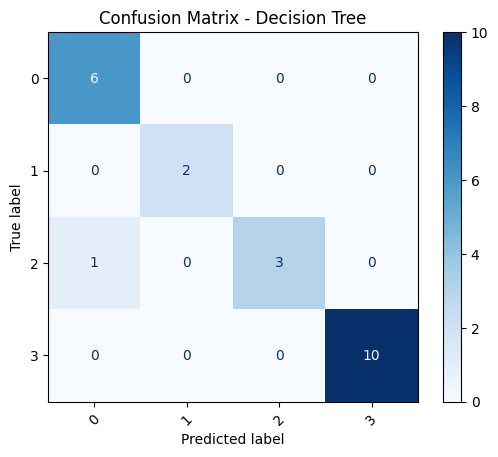

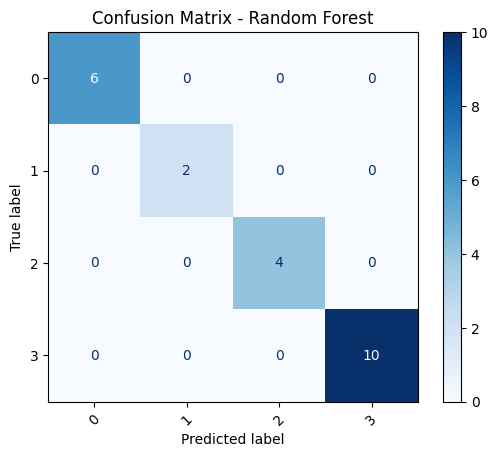

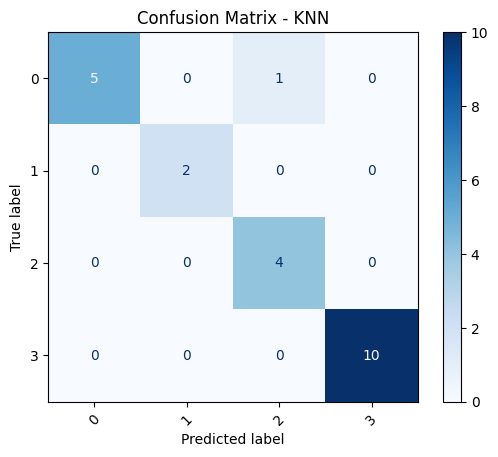

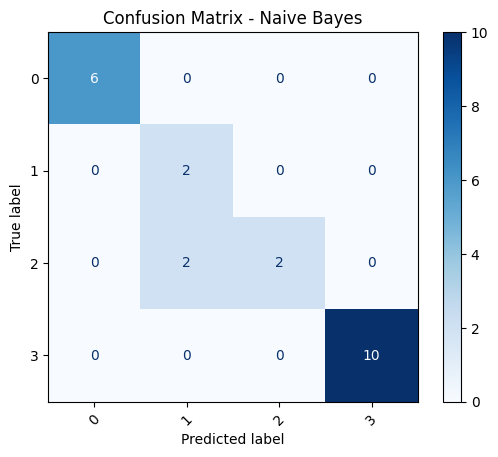

In [80]:
for name, y_pred in all_predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

<Figure size 800x600 with 0 Axes>

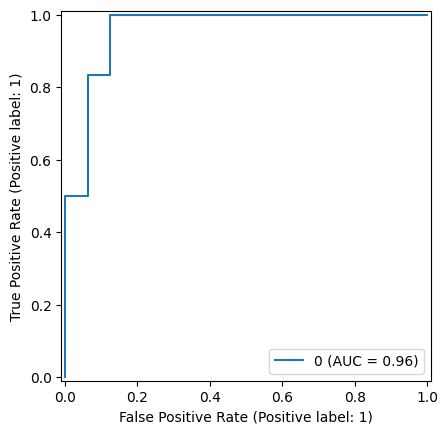

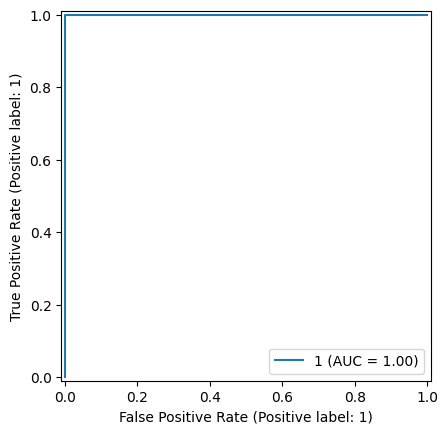

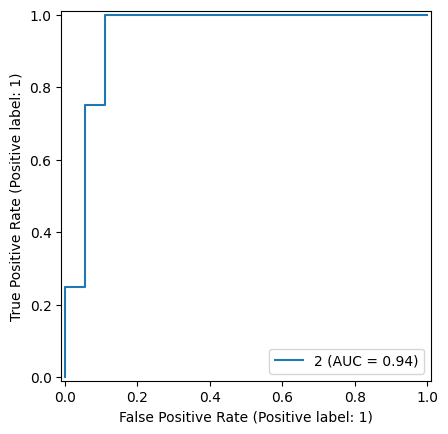

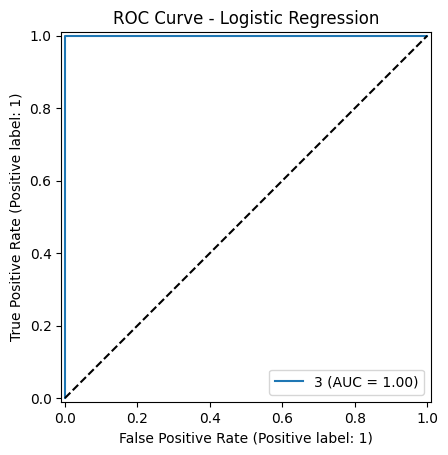

<Figure size 800x600 with 0 Axes>

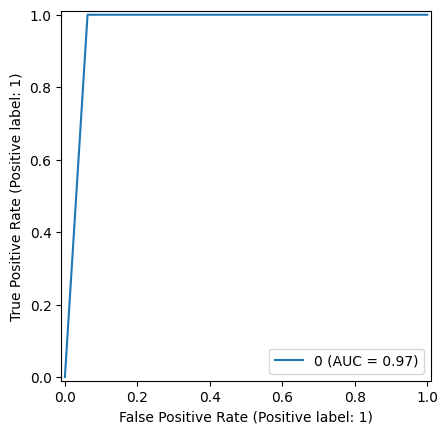

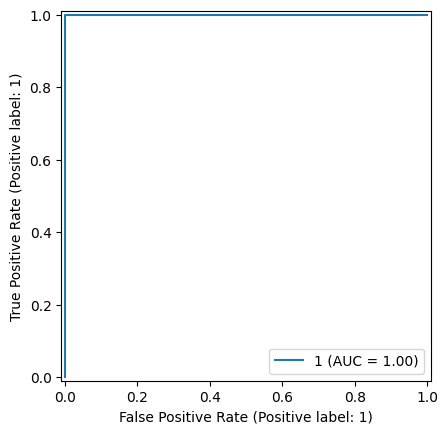

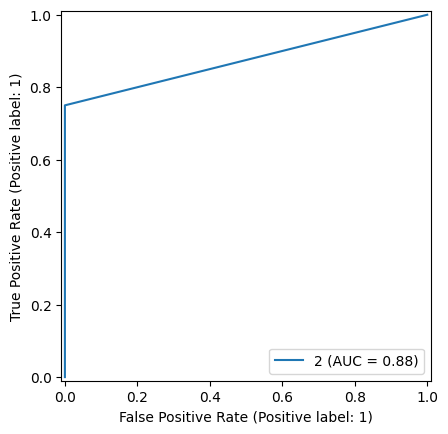

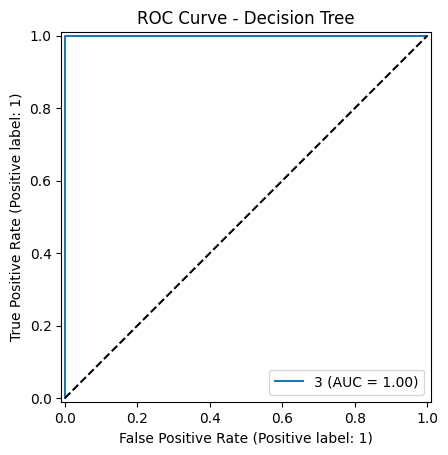

<Figure size 800x600 with 0 Axes>

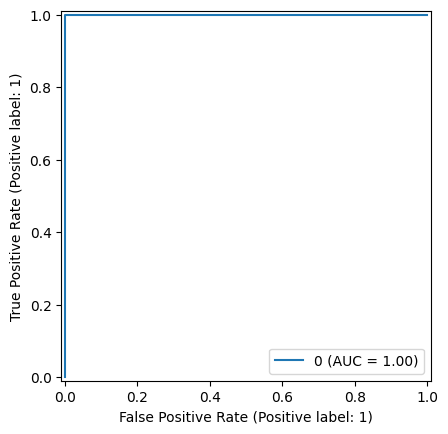

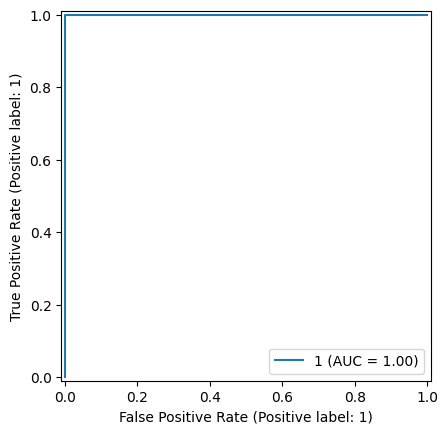

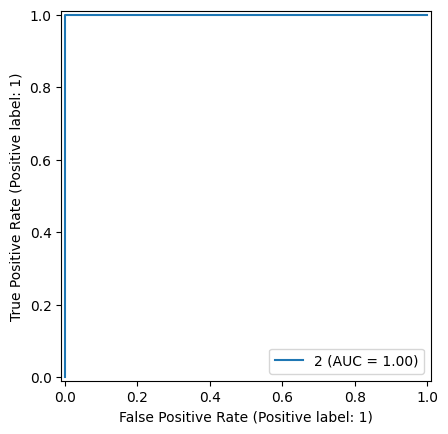

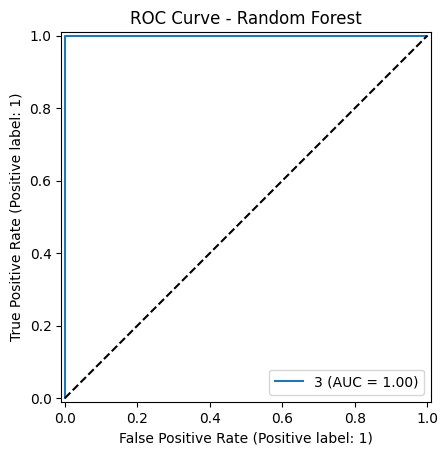

<Figure size 800x600 with 0 Axes>

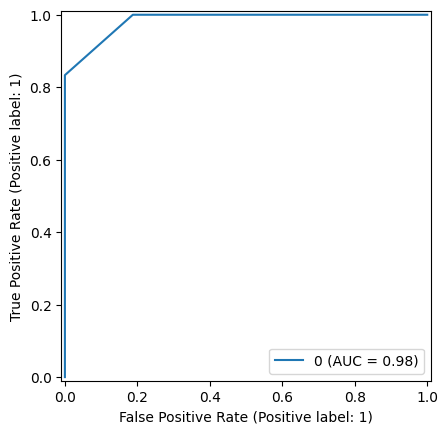

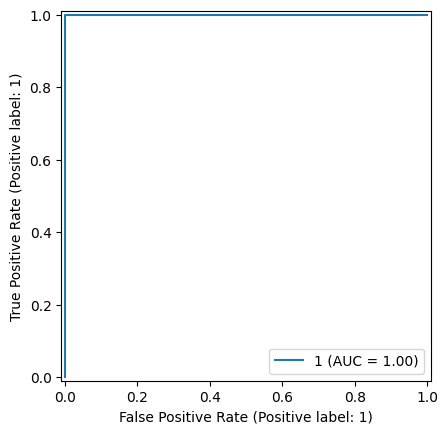

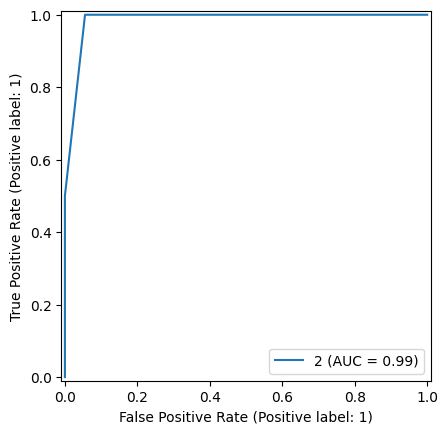

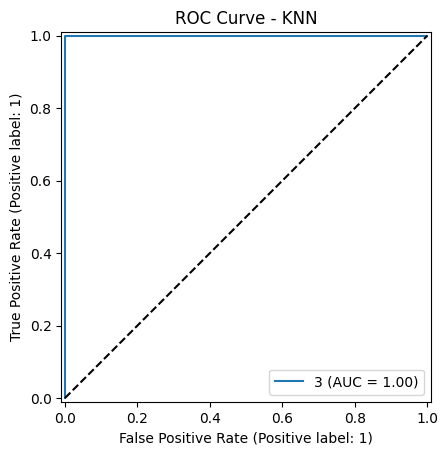

<Figure size 800x600 with 0 Axes>

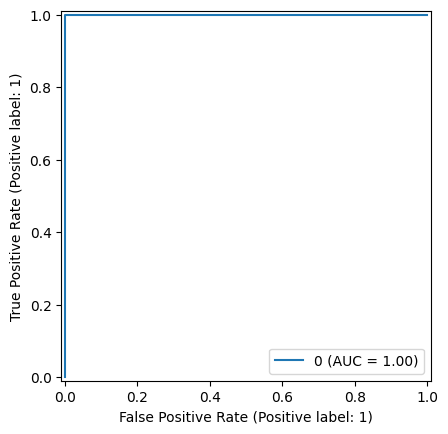

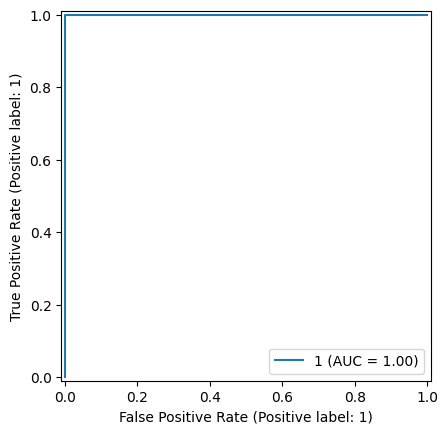

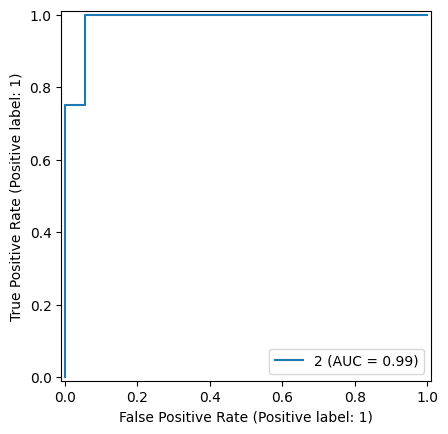

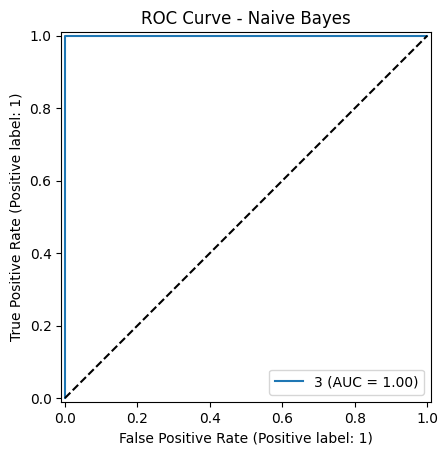

In [81]:
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)

        y_test_bin = label_binarize(y_test, classes=np.unique(y))
        n_classes = y_test_bin.shape[1]

        plt.figure(figsize=(8,6))

        for i in range(n_classes):
            RocCurveDisplay.from_predictions(
                y_test_bin[:, i],
                y_prob[:, i],
                name=f"{class_names[i]}"
            )

        plt.plot([0,1], [0,1], 'k--')
        plt.title(f"ROC Curve - {name}")
        plt.show()

In [82]:
# =========================
# FINAL RESULTS — Ranked by F1-Score
# =========================

results_df = pd.DataFrame(results, columns=[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'
])

# Sort by F1 Score
results_df = results_df.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("  FINAL RESULTS — Ranked by F1-Score")
print("=" * 60)

print(f"{'Rank':<5} {'Model':<22} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-" * 60)

for i, row in results_df.iterrows():
    tag = "  BEST" if i == 0 else "  WORST" if i == len(results_df)-1 else ""

    print(f"{i+1:<5} {row['Model']:<22} "
          f"{row['Precision']:>10.4f} "
          f"{row['Recall']:>8.4f} "
          f"{row['F1 Score']:>8.4f} "
          f"{row['ROC-AUC']:>8.4f}{tag}")

# =========================
# Best Model Info
# =========================
best_model_row = results_df.iloc[0]

print("\nBest Model :", best_model_row['Model'])
print("F1-Score   :", round(best_model_row['F1 Score'], 4))
print("ROC-AUC    :", round(best_model_row['ROC-AUC'], 4))
print("Precision  :", round(best_model_row['Precision'], 4))
print("Recall     :", round(best_model_row['Recall'], 4))


  FINAL RESULTS — Ranked by F1-Score
Rank  Model                   Precision   Recall       F1      AUC
------------------------------------------------------------
1     Random Forest              1.0000   1.0000   1.0000   1.0000  BEST
2     KNN                        0.9636   0.9545   0.9550   0.9932
3     Decision Tree              0.9610   0.9545   0.9530   0.9688
4     Naive Bayes                0.9545   0.9091   0.9091   0.9975
5     Logistic Regression        0.8615   0.8636   0.8591   0.9785  WORST

Best Model : Random Forest
F1-Score   : 1.0
ROC-AUC    : 1.0
Precision  : 1.0
Recall     : 1.0


In [83]:
# =========================
# Saving the Best Model
# =========================
import pickle

# Get best model name
best_model_name = results_df.iloc[0]['Model']

# Get actual model object
best_model = models[best_model_name]

# Save model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"\nBest model '{best_model_name}' saved successfully!")


Best model 'Random Forest' saved successfully!
